# Task 10 — Results analysis and end-to-end review

**Purpose.** Load every earlier run record and result file, run eleven
trace checks that connect them into one model-to-NPU path, draw the
final plots, and generate `results/final_report.html`.

**Environment.** Python 3.11 via `uv`, from the repo root:
`uv run jupyter lab notebooks/10_results_analysis.ipynb`.
No downloads, no GPU — this notebook only reads files in the repo.

**Lesson.** `docs/tasks/10-results-analysis-and-review.html`

Run all cells top to bottom. The last cell asserts the completion gate.


In [1]:
# Cell 2 — parameters and paths
import base64
import json
import statistics
from collections import defaultdict
from datetime import datetime, timezone
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt

# ---- Parameters you can change ------------------------------------
INCLUDE_BF16 = True   # False: plots and report use fp32 local rows only
PLOT_DPI = 150        # resolution of the saved PNG plots
# -------------------------------------------------------------------

ROOT = Path.cwd() if (Path.cwd() / "progress" / "state.json").exists() else Path.cwd().parent
assert (ROOT / "progress" / "state.json").exists(), (
    f"Cannot find the repo root from {Path.cwd()}. "
    "Start Jupyter from the repo root or the notebooks/ directory.")
RUNS = ROOT / "progress" / "runs"
RESULTS = ROOT / "results"
REPORT_PATH = RESULTS / "final_report.html"
PLOT_PATHS = {
    "ttft": RESULTS / "10_ttft_vs_prompt.png",
    "decode": RESULTS / "10_decode_vs_prompt.png",
    "quant": RESULTS / "10_quant_error.png",
    "gap": RESULTS / "10_deployment_gap.png",
}
print("repo root:", ROOT)


repo root: /Users/chayut/projects/qualcomm-edge-slm-lab


In [2]:
# Cell 3 — load the nine run records
runs = {}
for n in range(1, 10):
    p = RUNS / f"{n:02d}-run.json"
    assert p.exists(), f"missing run record: {p}"
    runs[n] = json.loads(p.read_text())

assert len(runs) == 9, "expected 9 run records"
for n, r in runs.items():
    assert r["task"] == n, f"task number mismatch in {n:02d}-run.json"
    assert r["status"] == "complete", f"task {n:02d} is not complete: {r['status']}"
    print(f"Task {n:02d}  {r['completed_at']}  {r['title']}")
print("\nall nine run records loaded, all complete")


Task 01  2026-08-14T09:38:50Z  Orientation, access, and stack map
Task 02  2026-08-17T15:17:08Z  Qwen architecture and Hugging Face baseline
Task 03  2026-08-18T15:12:28Z  Manual decoding and KV cache
Task 04  2026-08-19T14:29:06Z  Static graph contracts and ONNX
Task 05  2026-08-19T17:19:02Z  Qualcomm's Qwen model adapter
Task 06  2026-08-19T21:17:11Z  Quantization and AIMET concepts
Task 07  2026-08-20T16:15:00Z  Published W4A16 artifact and AI Hub
Task 08  2026-08-20T18:00:00Z  QAIRT and GenieX on QDC
Task 09  2026-08-21T21:35:18Z  Small diagnostic benchmark

all nine run records loaded, all complete


In [3]:
# Cell 4 — load the result files
def _load(name):
    p = RESULTS / name
    assert p.exists(), f"missing result file: {p}"
    return json.loads(p.read_text())

data = {
    "cfg": _load("02_config_summary.json"),
    "params": _load("02_parameter_summary.json"),
    "trace03": _load("03_decode_trace.json"),
    "contracts04": _load("04_contracts.json"),
    "graph05": _load("05_graph_contract.json"),
    "quant06": _load("06_quant_error.json"),
    "manifest07": _load("07_artifact_manifest.json"),
    "jobs07": _load("07_hub_job.json"),
    "manifest08": _load("08_execution_manifest.json"),
    "geniex08": _load("08_qdc_geniex.json"),
}
bench_rows = [json.loads(l) for l in (RESULTS / "09_diag_bench.jsonl").read_text().splitlines() if l.strip()]
assert len(bench_rows) >= 70, f"expected the full benchmark set, got {len(bench_rows)} rows"
local_rows = [r for r in bench_rows if r["runtime"] == "pytorch_local"]
device_rows = [r for r in bench_rows if r["runtime"] != "pytorch_local"]
print(f"loaded {len(data)} result files and {len(bench_rows)} benchmark rows "
      f"({len(local_rows)} local, {len(device_rows)} device)")


loaded 10 result files and 77 benchmark rows (75 local, 2 device)


## Trace checks

Each check pulls values from **two or more independent files** and
compares them. A `PASS` means the joint between those stages holds.
Together the eleven checks cover the whole path from the Hugging Face
config to the benchmark rows.


In [4]:
# Cell 6 — the eleven trace checks
checks = []

def check(cid, joint, ok, evidence):
    checks.append({"id": cid, "joint": joint, "pass": bool(ok), "evidence": evidence})

cfg = data["cfg"]

# T01 — HF config identity, and head_dim decoupled from hidden/heads
ok = (cfg["hidden_size"] == 1024 and cfg["num_attention_heads"] == 16
      and cfg["num_key_value_heads"] == 8 and cfg["head_dim"] == 128
      and cfg["head_dim"] != cfg["hidden_size"] // cfg["num_attention_heads"])
check("T01", "HF config (Task 02)", ok,
      f"hidden=1024, 16 Q / 8 KV heads, head_dim=128; 1024/16=64 != 128")

# T02 — KV cache grows by exactly 1 per decode step
ok = True
ev = []
for key, tr in data["trace03"].items():
    expected = list(range(tr["prompt_len"] + 1, tr["prompt_len"] + tr["generated"]))
    ok &= (tr["kv_lens"] == expected
           and tr["final_kv_len"] == tr["prompt_len"] + tr["generated"] - 1)
    ev.append(f"n={key}: kv {tr['prompt_len']}->{tr['final_kv_len']} (+1/step)")
check("T02", "Decode loop (Task 03)", ok, "; ".join(ev))

# T03 — config -> cache size per token per layer
kv_per_token = 2 * cfg["num_key_value_heads"] * cfg["head_dim"]
ok = kv_per_token == data["params"]["kv_numbers_per_token_per_layer"]
check("T03", "Config -> KV cache (02 -> 03)", ok,
      f"2 x 8 x 128 = {kv_per_token} == recorded {data['params']['kv_numbers_per_token_per_layer']}")

# T04 — static ONNX contracts: fixed shapes, decode input [1, 1]
ok = True
for L in ("8", "16"):
    c = data["contracts04"][L]
    ok &= c["prefill"]["all_shapes_fixed"] and c["decode"]["all_shapes_fixed"]
    dec_in = {i["name"]: i["shape"] for i in c["decode"]["inputs"]}
    ok &= dec_in["input_ids"] == [1, 1]
check("T04", "Static graphs (Task 04)", ok,
      "all_shapes_fixed=true at P=8 and P=16; decode input_ids [1, 1]")

# T05 — config -> deployed Qualcomm graph shapes
g1 = data["graph05"]["1"]
g128 = data["graph05"]["128"]
pk = g1["inputs_head"]["past_key_0_in"]["shape"]
ok = (pk[0] == cfg["num_key_value_heads"] and pk[2] == cfg["head_dim"]
      and pk[3] == g1["context_length"] - 1
      and g128["inputs_head"]["input_ids"]["shape"] == [1, 128]
      and data["manifest08"]["qairt"]["kv_dim"] == cfg["head_dim"])
check("T05", "Config -> deployed graph (02 -> 05 -> 08)", ok,
      f"past_key_0_in {pk}: 8=KV heads, 128=head_dim, {pk[3]}={g1['context_length']}-1; kv_dim=128")

# T06 — one bundle, three independent size records; ratio to fp32
bytes07 = data["manifest07"]["totals"]["by_kind"]["qnn_context_binary"]["total_bytes"]
bytes08 = sum(f["size_bytes"] for f in data["manifest08"]["qnn_context_binary"]["files"])
sizes09 = {r["model_size_bytes"] for r in device_rows}
fp32_bytes = local_rows[0]["model_size_bytes"]
ratio = bytes07 / fp32_bytes
ok = bytes07 == bytes08 and sizes09 == {bytes07} and 0.2 < ratio < 0.45
check("T06", "Float model -> bundle (09 -> 07 -> 08)", ok,
      f"{bytes07:,} bytes in all three records; {ratio:.1%} of fp32 {fp32_bytes:,}")

# T07 — compile-time choices bound the run-time choices
m8 = data["manifest08"]
compiled = set(m8["qnn_context_binary"]["compiled_context_lengths"])
benched = set(m8["runtime_configuration"]["benchmark_context_lengths"])
cell_ctx = {c["context_length"] for s in data["geniex08"]["sessions"].values() for c in s["cells"]}
ok = (m8["chipset"]["soc"] == "sm8750" and benched <= compiled and cell_ctx <= compiled)
check("T07", "Compile time -> run time (Task 08)", ok,
      f"soc=sm8750; benchmarked -c {sorted(benched)} within compiled {sorted(compiled)}")

# T08 — unlike runtime paths always carry the warning
ok = (all(r["unlike_runtime_warning"] for r in device_rows)
      and not any(r["unlike_runtime_warning"] for r in local_rows))
check("T08", "Benchmark honesty (Task 09)", ok,
      f"{len(device_rows)} device rows warned, 0 of {len(local_rows)} local rows warned")

# T09 — reproducibility: fp32-a vs fp32-b hashes
sha = {rid: {(r["prompt_id"], r["rep"]): r["output_sha256"]
             for r in local_rows if r["run_id"] == rid}
       for rid in ("fp32-a", "fp32-b")}
pairs = set(sha["fp32-a"]) & set(sha["fp32-b"])
same = sum(sha["fp32-a"][k] == sha["fp32-b"][k] for k in pairs)
ok = len(pairs) == 24 and same == 24
check("T09", "Reproducibility (Task 09)", ok, f"{same}/{len(pairs)} output hashes identical")

# T10 — scaling directions, and the deployment gap
by_target = defaultdict(lambda: {"ttft": [], "decode": []})
for r in local_rows:
    if r["run_id"] == "fp32-a":
        by_target[r["target_tokens"]]["ttft"].append(r["ttft_ms"])
        by_target[r["target_tokens"]]["decode"].append(r["decode_tps"])
ttft_means = [statistics.mean(by_target[t]["ttft"]) for t in (32, 128, 512)]
dec_means = [statistics.mean(by_target[t]["decode"]) for t in (32, 128, 512)]
device_decode = min(r["decode_tps"] for r in device_rows)
local_max = max(r["decode_tps"] for r in local_rows if r["decode_tps"] is not None)
ok = (ttft_means == sorted(ttft_means) and dec_means == sorted(dec_means, reverse=True)
      and device_decode > local_max)
check("T10", "Scaling directions (Task 09)", ok,
      f"mean TTFT {['%.0f' % v for v in ttft_means]} ms rises; "
      f"mean decode {['%.1f' % v for v in dec_means]} tok/s falls; "
      f"device {device_decode:.0f} > local max {local_max:.1f} (unlike runtimes)")

# T11 — quantization error falls as bits rise (q_proj, group=128)
sweep = max(data["quant06"].values(), key=lambda s: len(s["records"]))
q128 = {}
for key, rec in sweep["records"].items():
    layer, bits_s, group_s = key.split("|")
    if layer == "q_proj" and group_s == "group=128" and "output_rel_error" in rec:
        q128[int(bits_s.split("=")[1])] = rec["output_rel_error"]
bits_sorted = sorted(q128)
errs = [q128[b] for b in bits_sorted]
ok = len(bits_sorted) >= 4 and errs == sorted(errs, reverse=True)
check("T11", "Quantization error (Task 06)", ok,
      f"q_proj@group=128: bits {bits_sorted} -> errors strictly falling "
      f"({errs[0]:.3f} down to {errs[-1]:.4f})")

# --- print the table
w = max(len(c["joint"]) for c in checks)
for c in checks:
    print(f"{c['id']}  {'PASS' if c['pass'] else 'FAIL'}  {c['joint']:<{w}}  {c['evidence']}")
n_pass = sum(c["pass"] for c in checks)
print(f"\n{n_pass}/{len(checks)} trace checks pass")
assert n_pass == len(checks), "at least one trace check failed — read the FAIL rows above"


T01  PASS  HF config (Task 02)                        hidden=1024, 16 Q / 8 KV heads, head_dim=128; 1024/16=64 != 128
T02  PASS  Decode loop (Task 03)                      n=16: kv 24->39 (+1/step); n=32: kv 24->43 (+1/step)
T03  PASS  Config -> KV cache (02 -> 03)              2 x 8 x 128 = 2048 == recorded 2048
T04  PASS  Static graphs (Task 04)                    all_shapes_fixed=true at P=8 and P=16; decode input_ids [1, 1]
T05  PASS  Config -> deployed graph (02 -> 05 -> 08)  past_key_0_in [8, 1, 128, 4095]: 8=KV heads, 128=head_dim, 4095=4096-1; kv_dim=128
T06  PASS  Float model -> bundle (09 -> 07 -> 08)     775,835,648 bytes in all three records; 32.5% of fp32 2,384,199,680
T07  PASS  Compile time -> run time (Task 08)         soc=sm8750; benchmarked -c [512, 4096] within compiled [512, 1024, 2048, 3072, 4096]
T08  PASS  Benchmark honesty (Task 09)                2 device rows warned, 0 of 75 local rows warned
T09  PASS  Reproducibility (Task 09)                  24/24 output h

## Final plots

Medians over the three measured repetitions per prompt. Local runs:
`fp32-a` (and `bf16` if `INCLUDE_BF16`). Device rows are already
median-of-3 from Task 08.


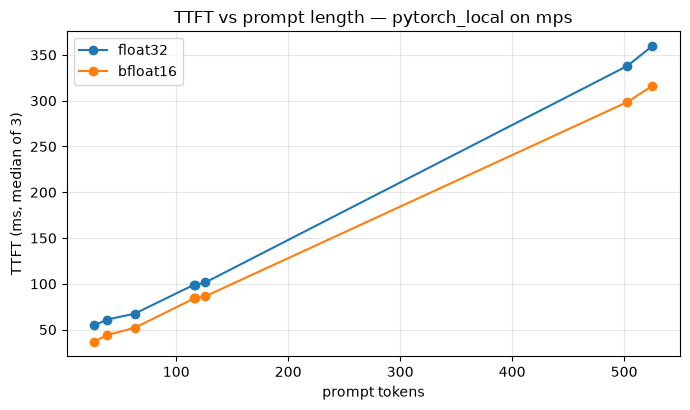

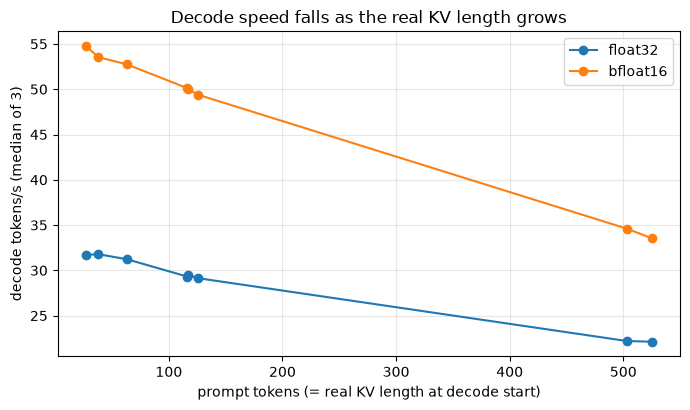

saved: 10_ttft_vs_prompt.png and 10_decode_vs_prompt.png


In [5]:
# Cell 8 — TTFT and decode vs prompt length (local)
def medians(run_id, field):
    per_prompt = defaultdict(list)
    for r in local_rows:
        if r["run_id"] == run_id and r[field] is not None:
            per_prompt[(r["prompt_tokens"], r["prompt_id"])].append(r[field])
    pts = sorted((p, statistics.median(v)) for (p, _), v in per_prompt.items())
    return [p for p, _ in pts], [m for _, m in pts]

series = [("fp32-a", "float32", "tab:blue")]
if INCLUDE_BF16:
    series.append(("bf16", "bfloat16", "tab:orange"))

fig, ax = plt.subplots(figsize=(7, 4.2))
for rid, label, color in series:
    x, y = medians(rid, "ttft_ms")
    ax.plot(x, y, "o-", label=label, color=color)
ax.set_xlabel("prompt tokens")
ax.set_ylabel("TTFT (ms, median of 3)")
ax.set_title("TTFT vs prompt length — pytorch_local on mps")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(PLOT_PATHS["ttft"], dpi=PLOT_DPI)
plt.show()

fig, ax = plt.subplots(figsize=(7, 4.2))
for rid, label, color in series:
    x, y = medians(rid, "decode_tps")
    ax.plot(x, y, "o-", label=label, color=color)
ax.set_xlabel("prompt tokens (= real KV length at decode start)")
ax.set_ylabel("decode tokens/s (median of 3)")
ax.set_title("Decode speed falls as the real KV length grows")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(PLOT_PATHS["decode"], dpi=PLOT_DPI)
plt.show()
print("saved:", PLOT_PATHS["ttft"].name, "and", PLOT_PATHS["decode"].name)


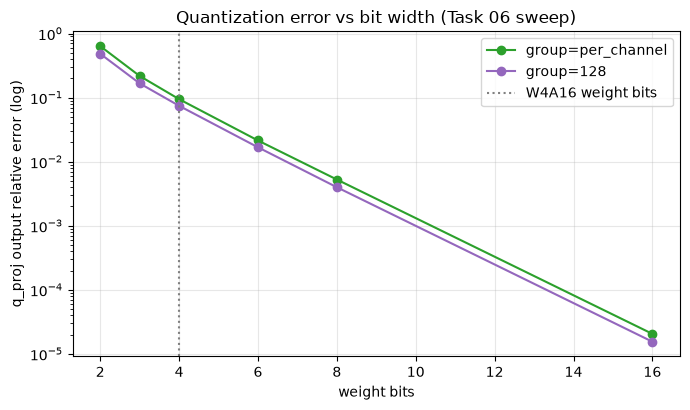

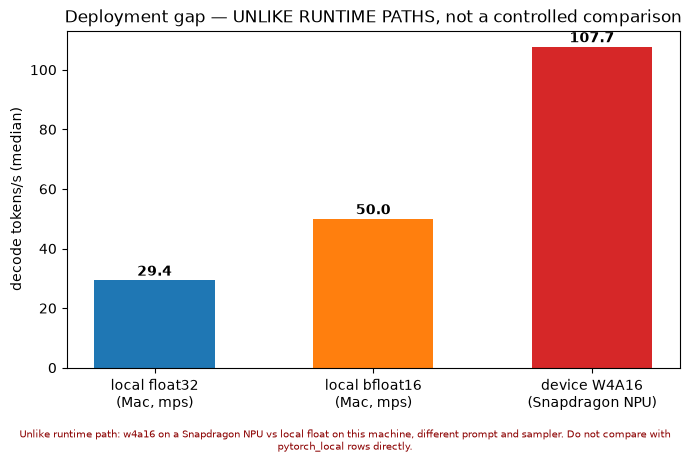

saved: 10_quant_error.png and 10_deployment_gap.png


In [6]:
# Cell 9 — quantization error and the deployment gap
fig, ax = plt.subplots(figsize=(7, 4.2))
for group, color in (("per_channel", "tab:green"), ("128", "tab:purple")):
    pts = {}
    for key, rec in sweep["records"].items():
        layer, bits_s, group_s = key.split("|")
        if layer == "q_proj" and group_s == f"group={group}" and "output_rel_error" in rec:
            pts[int(bits_s.split("=")[1])] = rec["output_rel_error"]
    xs = sorted(pts)
    ax.plot(xs, [pts[b] for b in xs], "o-", label=f"group={group}", color=color)
ax.axvline(4, color="gray", linestyle=":", label="W4A16 weight bits")
ax.set_yscale("log")
ax.set_xlabel("weight bits")
ax.set_ylabel("q_proj output relative error (log)")
ax.set_title("Quantization error vs bit width (Task 06 sweep)")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(PLOT_PATHS["quant"], dpi=PLOT_DPI)
plt.show()

WARNING_TEXT = device_rows[0]["unlike_runtime_warning"]
bars = [("local float32\n(Mac, mps)",
         statistics.median(r["decode_tps"] for r in local_rows
                           if r["run_id"] == "fp32-a" and r["decode_tps"] is not None))]
if INCLUDE_BF16:
    bars.append(("local bfloat16\n(Mac, mps)",
                 statistics.median(r["decode_tps"] for r in local_rows
                                   if r["run_id"] == "bf16" and r["decode_tps"] is not None)))
bars.append(("device W4A16\n(Snapdragon NPU)",
             statistics.median(r["decode_tps"] for r in device_rows)))

fig, ax = plt.subplots(figsize=(7, 4.6))
names = [b[0] for b in bars]
vals = [b[1] for b in bars]
colors = ["tab:blue", "tab:orange", "tab:red"][:len(bars) - 1] + ["tab:red"]
ax.bar(names, vals, color=colors[:len(bars)], width=0.55)
for i, v in enumerate(vals):
    ax.text(i, v + 1.5, f"{v:.1f}", ha="center", fontweight="bold")
ax.set_ylabel("decode tokens/s (median)")
ax.set_title("Deployment gap — UNLIKE RUNTIME PATHS, not a controlled comparison")
fig.text(0.5, 0.01, WARNING_TEXT, ha="center", fontsize=7, wrap=True, color="darkred")
fig.tight_layout(rect=(0, 0.06, 1, 1))
fig.savefig(PLOT_PATHS["gap"], dpi=PLOT_DPI)
plt.show()
print("saved:", PLOT_PATHS["quant"].name, "and", PLOT_PATHS["gap"].name)


In [7]:
# Cell 10 — limitations, assembled from real records
limitations = []

for jid, job in data["jobs07"]["jobs"].items():
    if job["status"]["code"] == "FAILED":
        msg = job["status"]["message"].split(".")[0]
        limitations.append({
            "source": f"Task 07 hosted job {jid}",
            "text": f"Profile job failed: {msg}. Fixed by naming a graph with "
                    "context_enable_graphs; recorded as a real failure."})

limitations.append({
    "source": "Task 09 device rows",
    "text": WARNING_TEXT})
limitations.append({
    "source": "Task 08 runtime configuration",
    "text": "Device runs used the bundle's default sampler "
            f"(seed {data['manifest08']['runtime_configuration']['sampler']['seed']}, "
            f"temp {data['manifest08']['runtime_configuration']['sampler']['temp']}), "
            "while local runs used greedy decoding. Outputs are not comparable "
            "token for token."})
limitations.append({
    "source": "Task 09 method",
    "text": "peak_rss_bytes is the process-wide cumulative peak, so later runs "
            "in the same process can only report equal or larger values."})
limitations.append({
    "source": "Project scope",
    "text": "One model (Qwen3-0.6B), one chipset (sm8750), one device family. "
            "No W16A16 or float device asset exists for this model, so the "
            "accuracy baseline is the local Hugging Face float model."})
limitations.append({
    "source": "Task 08 finding, refined in Task 09",
    "text": "The phone showed no decode-speed change between -c 512 and 4096 "
            "because the real prompt stayed at 128 tokens. Testing the "
            "real-KV-length effect on device needs longer real prompts."})

for l in limitations:
    print(f"- [{l['source']}] {l['text'][:100]}")
print(f"\n{len(limitations)} limitations recorded")


- [Task 07 hosted job jp8x0x8og] Profile job failed: Failed to profile the model: Models with multiple graphs must specify a graph na
- [Task 07 hosted job jgk474dnp] Profile job failed: Failed to profile the model: Models with multiple graphs must specify a graph na
- [Task 09 device rows] Unlike runtime path: w4a16 on a Snapdragon NPU vs local float on this machine, different prompt and 
- [Task 08 runtime configuration] Device runs used the bundle's default sampler (seed 42, temp 0.8), while local runs used greedy deco
- [Task 09 method] peak_rss_bytes is the process-wide cumulative peak, so later runs in the same process can only repor
- [Project scope] One model (Qwen3-0.6B), one chipset (sm8750), one device family. No W16A16 or float device asset exi
- [Task 08 finding, refined in Task 09] The phone showed no decode-speed change between -c 512 and 4096 because the real prompt stayed at 12

7 limitations recorded


In [8]:
# Cell 11 — generate results/final_report.html
def img64(path):
    return "data:image/png;base64," + base64.b64encode(path.read_bytes()).decode()

def esc(s):
    return str(s).replace("&", "&amp;").replace("<", "&lt;").replace(">", "&gt;")

m8 = data["manifest08"]
cells08 = [c for s in data["geniex08"]["sessions"].values() for c in s["cells"]]
best_dev = max(cells08, key=lambda c: c["decode_tps"])
tok_job = next(j for j in data["jobs07"]["jobs"].values()
               if j["status"]["code"] == "SUCCESS" and "part2 token" in j["job_name"])
pro_job = next(j for j in data["jobs07"]["jobs"].values()
               if j["status"]["code"] == "SUCCESS" and "part2 prompt" in j["job_name"])
fp32_ttft = dict(zip(*medians("fp32-a", "ttft_ms")))
fp32_dec = dict(zip(*medians("fp32-a", "decode_tps")))
p_min, p_max = min(fp32_ttft), max(fp32_ttft)

stages = [
    ("1. Hugging Face model", "Tasks 01–02", [
        ("Model", "Qwen/Qwen3-0.6B, 596,049,920 parameters (tied embeddings)"),
        ("Architecture", f"{cfg['num_hidden_layers']} layers, hidden {cfg['hidden_size']}, "
         f"{cfg['num_attention_heads']} query / {cfg['num_key_value_heads']} KV heads, "
         f"head_dim {cfg['head_dim']}"),
        ("Float size", f"{fp32_bytes:,} bytes (fp32, from benchmark rows)")]),
    ("2. Autoregressive decode and KV cache", "Task 03", [
        ("KV growth", "exactly +1 token per decode step "
         f"({data['trace03']['16']['prompt_len']} -> {data['trace03']['16']['final_kv_len']} "
         "at 16 generated tokens)"),
        ("Cache cost", f"{kv_per_token} numbers per token per layer = 2 x 8 KV heads x 128"),
        ("Match", "manual greedy loop matched model.generate at both lengths")]),
    ("3. Static graph contracts (ONNX)", "Task 04", [
        ("Shapes", "all_shapes_fixed = true; prefill input [1, P], decode input [1, 1]"),
        ("Numerics", "ONNX matched PyTorch under 1e-4 (observed ~1e-6)"),
        ("Contract", "decode carries 28 x 2 explicit past KV tensors in and out")]),
    ("4. Qualcomm model adapter", "Task 05", [
        ("Split", "part 1: token embedding; part 2: all transformer layers + LM head"),
        ("Deployed contract", f"{g128['num_inputs']} inputs / {g128['num_outputs']} outputs; "
         f"past_key_0_in {esc(pk)}"),
        ("Why 4095", "the graph produces the current token's KV itself")]),
    ("5. Quantization (W4A16)", "Task 06", [
        ("Meaning", "4-bit weights, 16-bit activations"),
        ("Error at 4 bits", f"q_proj output relative error {q128[4]:.3f} at group=128"),
        ("Recipe", "SpinQuant R2 + R3 -> AdaScale -> calibration (Qualcomm published)")]),
    ("6. Published bundle and AI Hub", "Task 07", [
        ("Bundle", f"{bytes07:,} bytes, 2 QNN context binaries, 10 graphs each"),
        ("Prompt vs token graph", f"prompt_ar128 {pro_job['metrics']['estimated_inference_time_us']/1000:.1f} ms "
         f"for 128 tokens vs token_ar1 {tok_job['metrics']['estimated_inference_time_us']/1000:.1f} ms "
         "for 1 token — why prefill batches"),
        ("Failures", "2 profile jobs failed until a graph name was given "
         "(multi-graph binaries require context_enable_graphs)")]),
    ("7. Device execution (QAIRT + GenieX)", "Task 08", [
        ("Stack", f"QAIRT {m8['qairt']['version']}, backend {m8['qairt']['backend']}, "
         f"chipset {m8['chipset']['name']} ({m8['chipset']['soc']}, HTP v{m8['chipset']['htp_version']})"),
        ("Best cell", f"{best_dev['cell_id']}: TTFT {best_dev['ttft_ms']} ms, "
         f"decode {best_dev['decode_tps']:.1f} tok/s, prefill {best_dev['prefill_tps']:.0f} tok/s"),
        ("Compiled vs runtime", f"context lengths {sorted(compiled)} fixed at compile time; "
         "-c, sampler, threads chosen at run time")]),
    ("8. Diagnostic benchmark", "Task 09", [
        ("Result set", f"{len(bench_rows)} JSONL rows, {len(device_rows)} device rows with warnings"),
        ("TTFT scaling", f"{fp32_ttft[p_min]:.0f} ms at {p_min} tokens -> "
         f"{fp32_ttft[p_max]:.0f} ms at {p_max} tokens (sublinear)"),
        ("Decode vs real KV", f"{fp32_dec[p_min]:.1f} -> {fp32_dec[p_max]:.1f} tok/s "
         "as the real cache grows"),
        ("Reproducibility", "all 24 output hashes identical across two fp32 runs")]),
]

concepts = [
    ("Prefill vs one-token decode",
     "Prefill runs all P prompt tokens in one parallel pass and fills the cache; "
     "decode produces one token per serial pass.",
     f"local TTFT {fp32_ttft[p_min]:.0f} ms for {p_min} tokens vs "
     f"{1000/fp32_dec[p_min]:.0f} ms per decoded token"),
    ("KV cache contents and growth",
     "Per-layer key and value tensors; the sequence-length dimension grows by 1 per step.",
     "Task 03 trace: kv length 24 -> 39, +1 every step"),
    ("Why GQA uses fewer KV heads",
     "8 KV heads serve 16 query heads, halving KV-cache memory and bandwidth.",
     "config: 16 query / 8 KV heads"),
    ("Why head_dim can differ from hidden/heads",
     "head_dim is its own config value; projections map 1024 -> 16 x 128 = 2048.",
     "head_dim 128 while 1024/16 = 64"),
    ("Why NPU compilers want fixed shapes",
     "Fixed shapes let the compiler plan memory and schedule every op ahead of time.",
     "all_shapes_fixed=true; deployed graphs only at [1,128] and [1,1]"),
    ("What crosses the model-part boundary",
     "Part 1 (embedding) hands hidden states to part 2 (layers + LM head); masks, "
     "RoPE cos/sin, and 28 x 2 KV tensors cross the graph interface.",
     f"{g128['num_inputs']} inputs / {g128['num_outputs']} outputs"),
    ("What W4A16 means",
     "Weights stored in 4 bits, activations computed in 16 bits.",
     f"bundle {bytes07/2**20:.0f} MiB = {ratio:.0%} of the fp32 model"),
    ("Calibration data and encodings",
     "Calibration inputs expose activation ranges; encodings are the stored "
     "scales/offsets mapping float values to the integer grid.",
     f"Task 06: group=128 stores {sweep['records']['q_proj|bits=4|group=128']['num_scales']:,} "
     f"scales for q_proj vs 1 per-tensor; error {q128[4]:.3f} vs "
     f"{sweep['records']['q_proj|bits=4|group=per_tensor']['output_rel_error']:.3f} at 4 bits"),
    ("What SpinQuant and AdaScale improve",
     "SpinQuant rotations spread outlier values before quantization; AdaScale learns "
     "better scales. Both cut the error the 4-bit grid causes.",
     "recipe: SpinQuant R2 + R3 -> AdaScale -> calibration"),
    ("ONNX vs QNN context binary vs QAIRT vs GenieX",
     "ONNX describes the graph portably; the context binary is that graph compiled "
     "for one chipset; QAIRT loads and runs it on the NPU; GenieX drives "
     "prefill/decode on top.",
     f"QAIRT {m8['qairt']['version']} ran the sm8750 binary via the qairt plugin"),
    ("Why a bundle is chipset- and compile-time-bound",
     "Graphs, weights, quantization, and context lengths are baked in at compile "
     "time for one HTP architecture.",
     f"-c must be one of {sorted(compiled)}; others fail"),
    ("Why TTFT and decode tok/s stay separate",
     "They measure different phases that scale differently; one blended number "
     "hides both.",
     f"device: 6480 tok/s prefill vs {best_dev['decode_tps']:.0f} tok/s decode — 60x apart"),
]

now = datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M UTC")
rows_html = "".join(
    f"<tr><td>{c['id']}</td><td>{esc(c['joint'])}</td>"
    f"<td class='{'ok' if c['pass'] else 'bad'}'>{'PASS' if c['pass'] else 'FAIL'}</td>"
    f"<td>{esc(c['evidence'])}</td></tr>" for c in checks)
stages_html = "".join(
    "<details><summary><strong>" + esc(t) + "</strong> <span class='muted'>" + esc(src)
    + "</span></summary><ul>"
    + "".join(f"<li><strong>{esc(k)}:</strong> {esc(v)}</li>" for k, v in items)
    + "</ul></details>" for t, src, items in stages)
concepts_html = "".join(
    f"<tr><td>{i+1}</td><td><strong>{esc(q)}</strong><br>{esc(a)}</td><td>{esc(ev)}</td></tr>"
    for i, (q, a, ev) in enumerate(concepts))
limits_html = "".join(
    f"<li><strong>{esc(l['source'])}:</strong> {esc(l['text'])}</li>" for l in limitations)
plots_html = "".join(
    f"<figure><img src='{img64(p)}' alt='{name} plot'></figure>"
    for name, p in PLOT_PATHS.items())

report = f"""<!DOCTYPE html>
<html lang="en"><head><meta charset="utf-8">
<meta name="viewport" content="width=device-width, initial-scale=1">
<title>Final report — Qualcomm Edge SLM Lab</title>
<style>
body {{ font-family: -apple-system, "Segoe UI", Roboto, sans-serif; margin: 0;
  color: #1a1d21; background: #fff; line-height: 1.6; }}
main {{ max-width: 920px; margin: 0 auto; padding: 1.5rem 1.25rem 4rem; }}
h1 {{ font-size: 1.6rem; }} h2 {{ font-size: 1.25rem; margin-top: 2rem; }}
table {{ border-collapse: collapse; width: 100%; font-size: 0.9rem; }}
th, td {{ border: 1px solid #d7dce2; padding: 0.45rem 0.6rem; text-align: left;
  vertical-align: top; }}
th {{ background: #f5f7f9; }}
.ok {{ color: #1c7c3c; font-weight: 700; }} .bad {{ color: #b02a2a; font-weight: 700; }}
.muted {{ color: #5a6270; font-size: 0.85em; }}
details {{ border: 1px solid #d7dce2; border-radius: 8px; padding: 0.5rem 0.9rem;
  margin: 0.5rem 0; }}
details[open] {{ background: #f5f7f9; }}
summary {{ cursor: pointer; }}
figure {{ margin: 1rem 0; }} img {{ max-width: 100%; border: 1px solid #d7dce2; }}
.warnbox {{ background: #fdeaea; border-left: 4px solid #b02a2a; padding: 0.6rem 0.9rem; }}
</style></head><body><main>
<h1>Qualcomm Edge SLM Lab — Final report</h1>
<p class="muted">Generated {now} by notebooks/10_results_analysis.ipynb
from the run records and result files in this repository. No number in
this report was typed by hand.</p>
<p><strong>{n_pass}/{len(checks)} trace checks pass.</strong>
Qwen/Qwen3-0.6B was followed from a Hugging Face float model
({fp32_bytes:,} bytes) to a W4A16 QNN context binary ({bytes07:,} bytes)
decoding at {best_dev['decode_tps']:.1f} tokens/s on a Snapdragon 8 Elite NPU.</p>
<h2>Pipeline trace (click a stage to open its evidence)</h2>
{stages_html}
<h2>Trace checks</h2>
<table><thead><tr><th>ID</th><th>Joint</th><th>Result</th><th>Evidence</th></tr></thead>
<tbody>{rows_html}</tbody></table>
<h2>Plots</h2>
<div class="warnbox">The deployment-gap chart compares unlike runtime
paths. It shows the deployment gain, not a controlled precision
comparison.</div>
{plots_html}
<h2>The twelve concepts, answered by the data</h2>
<table><thead><tr><th>#</th><th>Concept</th><th>Evidence from this project</th></tr></thead>
<tbody>{concepts_html}</tbody></table>
<h2>Limitations and recorded failures</h2>
<ul>{limits_html}</ul>
<footer class="muted"><p>Pinned reference: qualcomm/ai-hub-models
v0.59.0. Sources: progress/runs/01-run.json … 09-run.json and the
results/ files listed in the Task 10 lesson.</p></footer>
</main></body></html>
"""
REPORT_PATH.write_text(report)
print(f"wrote {REPORT_PATH} ({REPORT_PATH.stat().st_size:,} bytes)")
print("open it in a browser and click the pipeline stages")


wrote /Users/chayut/projects/qualcomm-edge-slm-lab/results/final_report.html (340,005 bytes)
open it in a browser and click the pipeline stages


In [9]:
# Cell 12 — automated summary: the completion gate
gate = {
    "nine_run_records_loaded": len(runs) == 9,
    "all_trace_checks_pass": n_pass == len(checks) == 11,
    "plots_exist": all(p.exists() and p.stat().st_size > 5_000 for p in PLOT_PATHS.values()),
    "report_exists": REPORT_PATH.exists() and REPORT_PATH.stat().st_size > 50_000,
    "limitations_recorded": len(limitations) >= 5,
}
for name, ok in gate.items():
    print(f"{'PASS' if ok else 'FAIL'}  {name}")
assert all(gate.values()), "gate not satisfied — see FAIL lines above"

print("\nArtifacts:")
for p in [*PLOT_PATHS.values(), REPORT_PATH]:
    print(f"  {p.relative_to(ROOT)}  ({p.stat().st_size:,} bytes)")
print(f"\nParameters: INCLUDE_BF16={INCLUDE_BF16}, PLOT_DPI={PLOT_DPI}")
print("\nAll checks pass. Open results/final_report.html in a browser,")
print("inspect the pipeline trace, then say: Review my current task")


PASS  nine_run_records_loaded
PASS  all_trace_checks_pass
PASS  plots_exist
PASS  report_exists
PASS  limitations_recorded

Artifacts:
  results/10_ttft_vs_prompt.png  (57,192 bytes)
  results/10_decode_vs_prompt.png  (57,643 bytes)
  results/10_quant_error.png  (79,353 bytes)
  results/10_deployment_gap.png  (51,382 bytes)
  results/final_report.html  (340,005 bytes)

Parameters: INCLUDE_BF16=True, PLOT_DPI=150

All checks pass. Open results/final_report.html in a browser,
inspect the pipeline trace, then say: Review my current task
